In [3]:
#10/12/2025

In [4]:
import sys
print(sys.version)

3.12.1 (tags/v3.12.1:2305ca5, Dec  7 2023, 22:03:25) [MSC v.1937 64 bit (AMD64)]


In [5]:
# Import the required libraries 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import json

In [6]:
print ("Read Dataset ... ")
def read_dataset(path):
  return json.load(open(path)) 

#Data = read_dataset('testfile2a.json')
Data = read_dataset('cooking_trainfile.json')

Read Dataset ... 


In [7]:
#Convert everything to lowercase.  Probably could clean up a little more
def generate_text(data):
  text_data = [" ".join(doc['ingredients']).lower() for doc in data]
  return text_data 

In [8]:
X = generate_text(Data)
Y = [doc['cuisine'] for doc in Data]

In [9]:
for i in range(5):
    print(Y[i],'|',X[i],'\n')

greek | romaine lettuce black olives grape tomatoes garlic pepper purple onion seasoning garbanzo beans feta cheese crumbles 

filipino | eggs pepper salt mayonaise cooking oil green chilies grilled chicken breasts garlic powder yellow onion soy sauce butter chicken livers 

indian | water vegetable oil wheat salt 

indian | black pepper shallots cornflour cayenne pepper onions garlic paste milk butter salt lemon juice water chili powder passata oil ground cumin boneless chicken skinless thigh garam masala double cream natural yogurt bay leaf 

jamaican | plain flour sugar butter eggs fresh ginger root salt ground cinnamon milk vanilla extract ground ginger powdered sugar baking powder 



In [10]:
print ("Divide into training and validation sets")
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

Divide into training and validation sets


In [11]:
print(len(X_train),len(y_train),len(X_test),len(y_test))

25454 25454 6364 6364


In [12]:
# Decided to use reg ex library (https://docs.python.org/3/library/re.html)
# Wanted to do this to "group words"
# For example, I noticed a couple ingredients consist of two words, but they 
# aren't connected via underscore, so they're treated differently.
# ex: soy and sauce should be one token
# Also, some ingredients are the same thing. Like cilantro and coriander.


import re

_PATTS = [
    # Cilantro is coriander, decided to group these two
    (re.compile(r"\bcoriander\b", re.I), "cilantro"),
    # scallions, spring onions, green onions should all be grouped into green_onion
    (re.compile(r"\b(scallions?|spring\s+onions?|green\s+onions?)\b", re.I), "green_onion"),
    # soy and sauce should be one phrase, soy_sauce
    (re.compile(r"\bsoy\s+sauce\b", re.I), "soy_sauce"),

    ## *I noticed accuracy for Jamaican was quite low (.15 accuracy on CM, confused
    ## with korean and russian, so I added some re.compiles for its cuisine
    (re.compile(r"\bjerk(\s+seasoning)?\b", re.I), "jerk_seasoning"),
  
    

    
]




In [13]:

def preprocess(s: str) -> str:
    s = s.lower()
    for rx, rep in _PATTS:
        s = rx.sub(rep, s)
    return s

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Built a modeling pipeleine, the TfidfVectorizer turns text numeric
# min_df = 4, so this ignores words that appear in fewer than 4 documents 
# min_df of 4 gave me the best test accuracy and had the best CM 
# Linear SVC (support vector classification)
# implements the preprocessor function from last cell
# ngram_range of 1,1 (1,2 yielded worse results)
# * class weight balanced because I noticed that cuisines like Italian or Thai had high accuracy,
# but other cuisines were very inaccurately matched
pipe = Pipeline([
    ("vec", TfidfVectorizer(
        preprocessor = preprocess,                 
        token_pattern=r"(?u)\b\w[\w_]+\b",          
        min_df=1, ngram_range=(1,1)
    )),
    ("clf", LinearSVC(C=1.0))
])

param_grid = {"clf__C": [0.5, 1.0, 2.0]}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
gs = GridSearchCV(pipe, param_grid, cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print("Test accuracy:", gs.score(X_test, y_test))


Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params: {'clf__C': 0.5}
Test accuracy: 0.7963544940289127


In [15]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
y_pred = gs.best_estimator_.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro", zero_division=0))
print("Weighted F1:", f1_score(y_test, y_pred, average="weighted", zero_division=0))
print("Macro Precision:", precision_score(y_test, y_pred, average="macro", zero_division=0))
print("Macro Recall:", recall_score(y_test, y_pred, average="macro", zero_division=0))


Accuracy: 0.7963544940289127
Macro F1: 0.728169825816362
Weighted F1: 0.7924359098653407
Macro Precision: 0.7692028185796556
Macro Recall: 0.700654182416532


In [16]:
import warnings
warnings.filterwarnings("ignore")  #not a great idea in general, but it cleans up the output when using scikit-learn
#obviously anything that triggers an error won't get ignored

from sklearn.neighbors import KNeighborsClassifier

In [17]:
#let's look at 20 predictions

for i in range(20):
    print(X_test[i],'|',y_test[i],'|',y_pred[i],'\n')

black pepper chopped green bell pepper garlic cloves italian salad dressing bouillon cube long-grain rice olive oil flavored cooking spray olive oil chopped onion boneless skinless chicken breast halves turkey breakfast sausage chopped celery hot water sliced green onions | cajun_creole | italian 

fresh cilantro salt stewed tomatoes chopped fresh chives serrano pepper garlic | mexican | mexican 

coriander seeds salt ghee saffron threads whole milk yoghurt cumin seed milk garlic fresh lemon juice fresh ginger root cayenne pepper chicken thighs | indian | indian 

mayonaise flour tortillas olive oil chipotle peppers shredded cheddar cheese salt asparagus | mexican | mexican 

bread giblet ground cayenne pepper oysters salt cooked white rice pepper chopped celery chopped parsley vegetable oil chopped onion | cajun_creole | cajun_creole 

seasoning pork sirloin chops pepper panko breadcrumbs eggs salt flour canola oil | korean | japanese 

green onions chili shredded cheddar cheese cream

In [18]:
# Overall predictions are pretty good

In [19]:
class_names =[]
for i in range(len(y_test)):
    if y_test[i] not in class_names:
        class_names.append(y_test[i])

In [20]:
#Confusion matrix stolen from
#https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
import matplotlib.pyplot as plt
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

Matplotlib is building the font cache; this may take a moment.


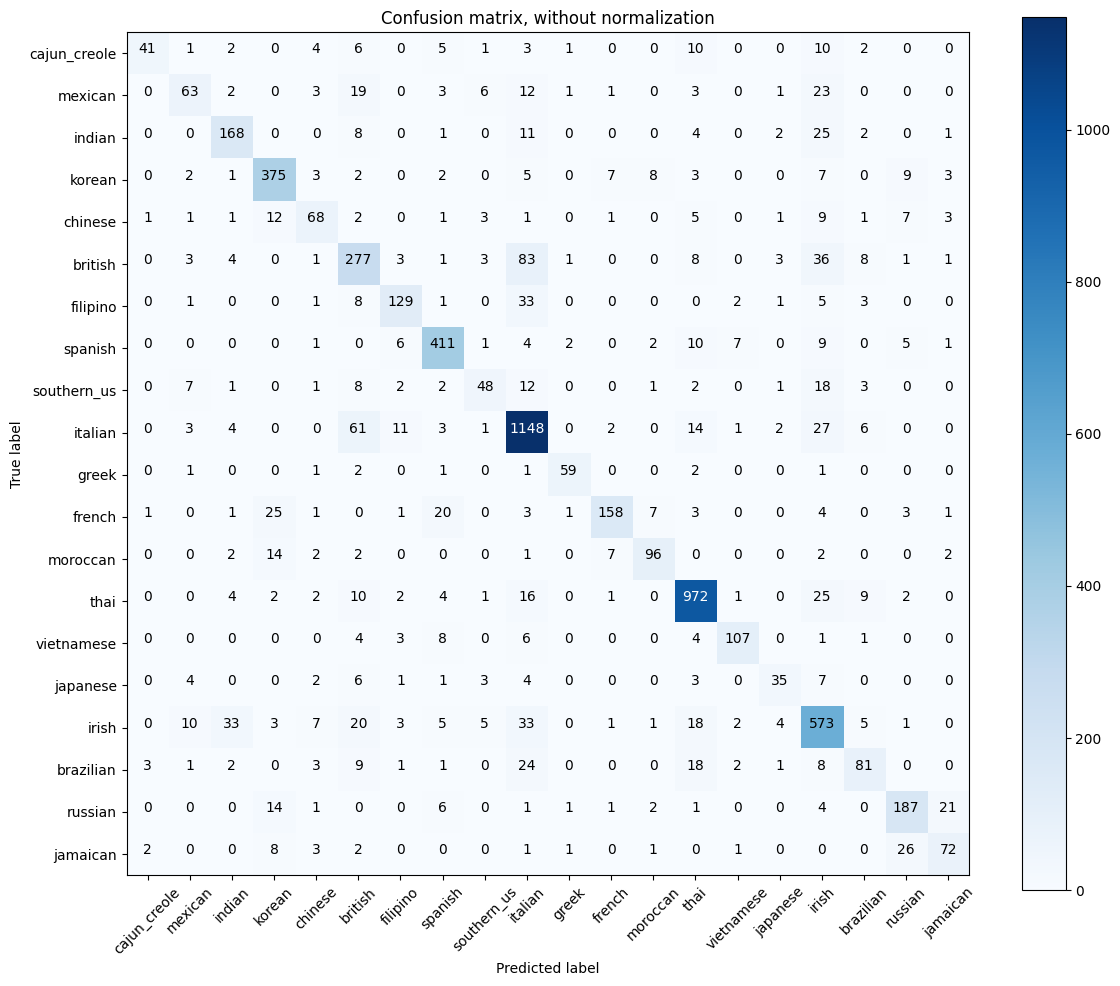

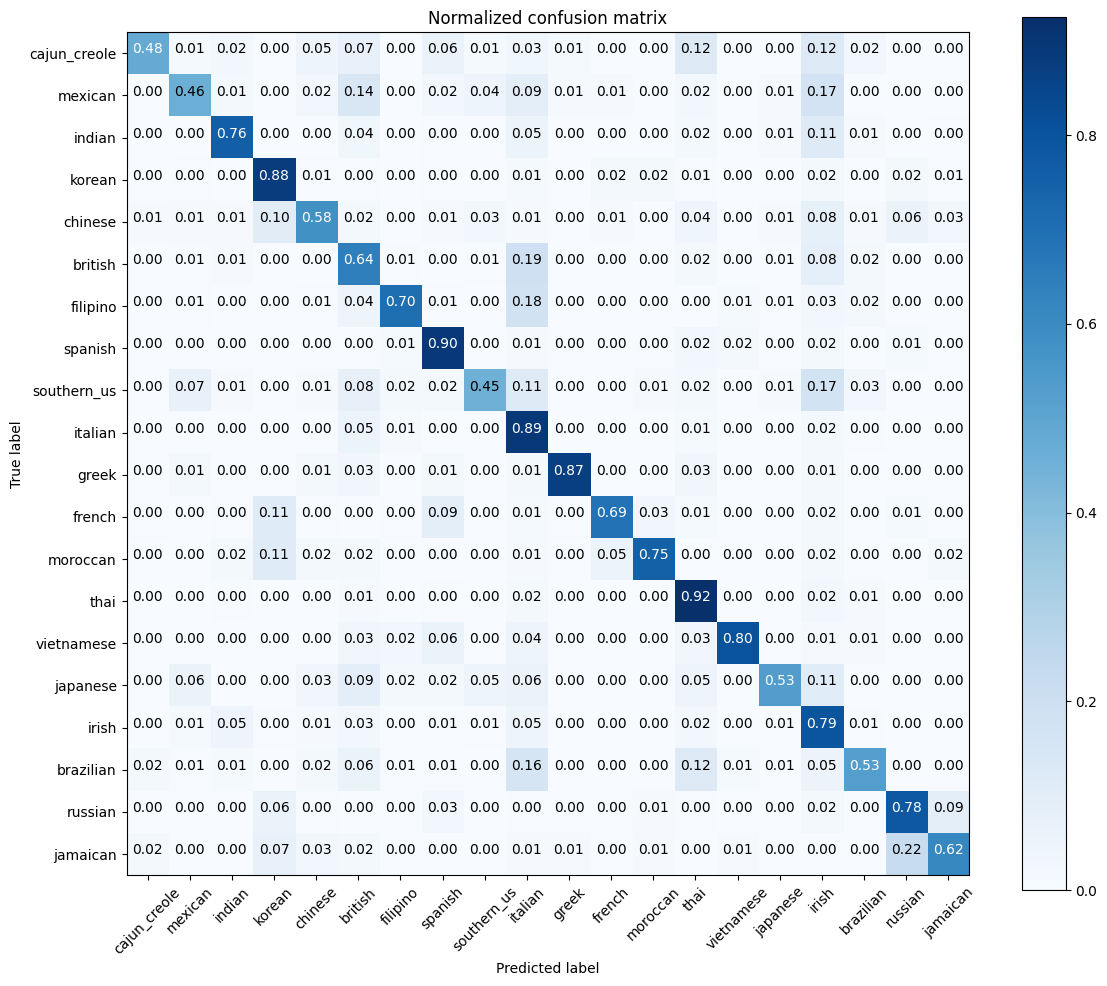

In [21]:
# Compute confusion matrix
#Confusion matrix stolen from
#https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html

from sklearn.metrics import confusion_matrix
import numpy as np

cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
plt.figure(figsize=(12, 10))
plot_confusion_matrix(cnf_matrix, classes=class_names,
                      title='Confusion matrix, without normalization')

plt.savefig("figure1.pdf", dpi="figure")
# Plot normalized confusion matrix
plt.figure(figsize=(12, 10))
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=True,
                      title='Normalized confusion matrix')

plt.savefig("figure2.pdf", dpi="figure")
plt.show()

In [22]:
import json, pandas as pd
import csv

with open("cooking_testfile.json", "r", encoding="utf-8") as f:
    data = json.load(f)

ids   = [d["id"] for d in data]
texts = [", ".join(d["ingredients"]) for d in data]  # <-- was the bug

best = gs.best_estimator_
pred = best.predict(texts)
out = pd.DataFrame({"id": ids, "cuisine": pred})
out.to_csv("cooking_output.csv", index=False)
print("Wrote cooking_output.csv with", len(out), "rows; last id:", out.iloc[-1,0])



Wrote cooking_output.csv with 7955 rows; last id: 905668
